In this workbook we show an example application of the entire workflow presented in this repository. 

In this workbook we will
- Analyze an example of AOD retrieval gaps.
- Apply our pre-trained gap-filling model.
- Use pre-trained random forest to relate satellite AOD to ground level PM2.5.

In [2]:
import os
import sys
import numpy as np
import pandas as pd
import rasterio as rio
import time
import tensorflow as tf
import re
import xarray as xr
import rioxarray
import glob

from skimage import io as skio
from skimage import util as skutil

# Import modules from lib/ directory
from lib.STpconvLayer import STpconv
from lib.STpconvUnet import STpconvUnet
from lib.DataGenerator import DataGenerator

import gc
import sys


from scipy.ndimage import gaussian_filter
DEMO_DATA_DIR = "/Volumes/External/data/pm_demo_data"


In [3]:
tif_paths = [
    f"{DEMO_DATA_DIR+'/GOES16_0.02'}_{j}.tif" for j in range(1140, 1140+36)]
arrays = [rioxarray.open_rasterio(
    tif_path).fillna(-3.4e+38) for tif_path in tif_paths]
input_data = xr.concat(arrays, dim='band')
# remove AOD lower than MERRA2 min
input_data = input_data.where(input_data >= 0.007162074, other=-3.4e+38)
# remove AOD higher than 5 updated on May 21, 2024
input_data = input_data.where(input_data < 5, other=-3.4e+38)
input_data['band'] = np.arange(1, 37)
input_data['x'] = input_data.x.round(2)
input_data['y'] = input_data.y.round(2)
iter_times = input_data.copy()
iter_times = iter_times.where(iter_times <= 0, 0)

/var/folders/d_/4hv15k7s6xd_m65h26npp7d40000gn/T/ipykernel_90074/574887408.py:19: FutureWarning: self.axes is deprecated since 2022.11 in order to align with matplotlibs plt.subplots, use self.axs instead.
  for ax in g.axes.flat:


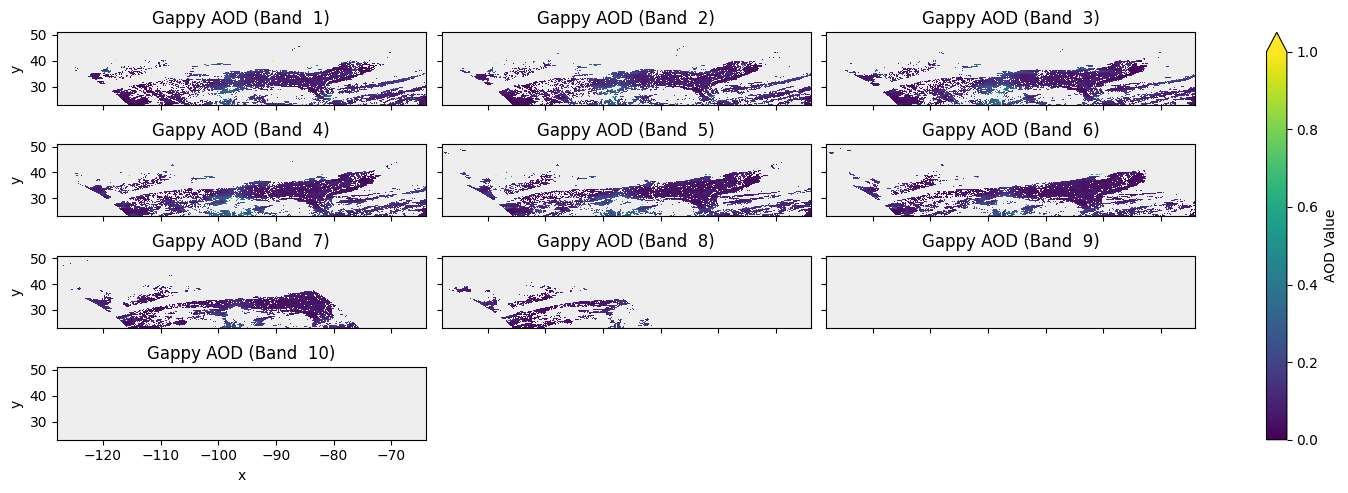

In [ ]:
import matplotlib.pyplot as plt

# 1. Select a few time steps to show the gaps (e.g., first 3 bands)
slices_to_plot = input_data.isel(band=slice(0, 3))

# 2. Mask the extreme fill values so they appear transparent/white
# We'll mask anything below 0 since your valid AOD starts at 0.007
masked_data = slices_to_plot.where(slices_to_plot > 0)

# 3. Plotting
g = masked_data.plot(
    x="x", y="y", col="band", col_wrap=3, 
    cmap="viridis", vmin=0, vmax=1, # AOD usually sits in this range
    figsize=(15, 5),
    cbar_kwargs={'label': 'AOD Value'}
)

# Cosmetic cleanup
for ax in g.axes.flat:
    ax.set_title(f"Gappy AOD (Band {ax.get_title().split('=')[-1]})")
    ax.set_facecolor('#eeeeee') # Light grey background to highlight the "holes"

plt.show()